In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 141s 1us/step


In [3]:
# Normalize images (scale pixel values to [0, 1])
x_train, x_test = x_train / 255.0, x_test / 255.0

# Flatten images (32x32x3 to 3072)
x_train = x_train.reshape(-1, 32*32*3)
x_test = x_test.reshape(-1, 32*32*3)

# Labels are (N,1) → flatten to (N,)
y_train = y_train.ravel()
y_test = y_test.ravel()

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(512, activation='relu', input_shape=(3072,)),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')  # 10 classes
])

c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

In [7]:
history = model.fit(x_train, y_train, epochs=20, batch_size=64, validation_split=0.2)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.3210 - loss: 1.8994 - val_accuracy: 0.3659 - val_loss: 1.7691
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.3913 - loss: 1.6903 - val_accuracy: 0.4015 - val_loss: 1.6933
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.4248 - loss: 1.6088 - val_accuracy: 0.4153 - val_loss: 1.6150
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.4452 - loss: 1.5512 - val_accuracy: 0.4453 - val_loss: 1.5735
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.4583 - loss: 1.5107 - val_accuracy: 0.4568 - val_loss: 1.5328
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.4736 - loss: 1.4718 - val_accuracy: 0.4626 - val_loss: 1.5267
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.4839 - loss: 1.4391 - val_accuracy: 0.4592 - val_loss: 1.5497
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.4938 - loss: 1.4151 - 

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5046 - loss: 1.4228
Test Accuracy: 0.5045999884605408


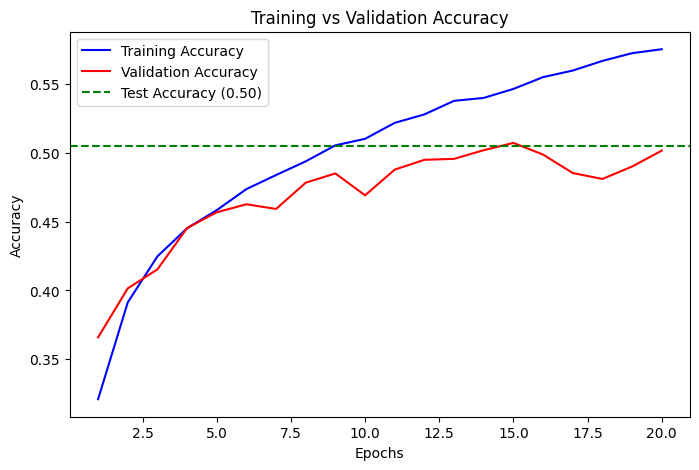

In [9]:
import matplotlib.pyplot as plt

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')

# Mark the final test accuracy
plt.axhline(y=test_acc, color='g', linestyle='--', label=f'Test Accuracy ({test_acc:.2f})')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
